# Machine Learning Assignment  -2
# Student ID :  2025AA05921
# Name : Kamaraj

# Loan Approval Classification - Model - 6 - XGBOOST

In [1]:
# Import the required libraries 
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
import time  
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV  
from sklearn.preprocessing import LabelEncoder 
import xgboost as xgb  
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report, roc_curve  
import warnings  
warnings.filterwarnings('ignore') 
import joblib
import os

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 1: Data Loading
# Read the dataset
train_data = pd.read_csv('../data/train_data.csv')
test_data = pd.read_csv('../data/test_data.csv')

print(f"Training data loaded: {train_data.shape}")
print(f"Test data loaded: {test_data.shape}")

# Combine for initial exploration
df_raw = pd.concat([train_data, test_data], ignore_index=True)

print(f"\nCombined dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print("\nFirst few rows:")
print(df_raw.head())


Training data loaded: (33750, 14)
Test data loaded: (11250, 14)

Combined dataset shape: (45000, 14)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

First few rows:
   person_age person_gender person_education  person_income  person_emp_exp  \
0        26.0        female        Associate       102675.0               5   
1        24.0          male         Bachelor        84036.0               0   
2        24.0        female         Bachelor        68237.0               2   
3        25.0        female        Associate        69530.0               0   
4        37.0        female        Associate       120992.0              12   

  person_home_ownership  loan_amnt        loan_intent  loan_int_rate  \
0              MORTGAGE     6000.0          EDUCATI

In [3]:
# Step 2:  EDA 
print("Dataset Information:")
print(df_raw.info())

print("\nTarget Variable Distribution:")
print(df_raw['loan_status'].value_counts())
print(f"Class Balance: {df_raw['loan_status'].value_counts(normalize=True).round(4)}") # Class  Distribution

print("\nMissing Values:")
print(df_raw.isnull().sum()) # Ensures that we have no missing values in the dataset

print("\nBasic Statistics:")
print(df_raw.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_lo

In [4]:
# Step 3: Categorical Encoding

df = df_raw.copy()  # Keep original safe

categorical_cols = [  # Categorical columns to encode
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]


# Store label encoders for each categorical column
label_encoders = {}

for col in categorical_cols:  # Encode each categorical column
    if col in df.columns:
        print(f"Encoding {col}:")
        print(f"  Original values: {df[col].unique()}")
        
        le = LabelEncoder()  # Label encoder instance
        df[col] = le.fit_transform(df[col].astype(str))  # Map categories to integers
        label_encoders[col] = le  # Store the encoder
        
        print(f"  Encoded values: {df[col].unique()}")


Encoding person_gender:
  Original values: ['female' 'male']
  Encoded values: [0 1]
Encoding person_education:
  Original values: ['Associate' 'Bachelor' 'High School' 'Master' 'Doctorate']
  Encoded values: [0 1 3 4 2]
Encoding person_home_ownership:
  Original values: ['MORTGAGE' 'RENT' 'OWN' 'OTHER']
  Encoded values: [0 3 2 1]
Encoding loan_intent:
  Original values: ['EDUCATION' 'DEBTCONSOLIDATION' 'MEDICAL' 'HOMEIMPROVEMENT' 'VENTURE'
 'PERSONAL']
  Encoded values: [1 0 3 2 5 4]
Encoding previous_loan_defaults_on_file:
  Original values: ['No' 'Yes']
  Encoded values: [0 1]


In [5]:
# Step 4: Feature and Target Separation

# Separate features (X) and target (y)
X = df.drop(columns=["loan_status"])  # All columns except target
y = df["loan_status"]  # Target variable only

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"Target classes: {y.unique()}")
print(f"Target distribution:")
print(y.value_counts())

Features (X) shape: (45000, 13)
Target (y) shape: (45000,)

Feature columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Target classes: [0 1]
Target distribution:
loan_status
0    35000
1    10000
Name: count, dtype: int64


In [6]:
# Step 5: Load Pre-Split Training and Test Data and Encode Categorical Features
# Use the same train/test split from Model 1 for consistency


# Separate features and target from training data
X_train = train_data.drop('loan_status', axis=1).copy()
y_train = train_data['loan_status']

# Separate features and target from test data
X_test = test_data.drop('loan_status', axis=1).copy()
y_test = test_data['loan_status']

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")


categorical_cols = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

label_encoders = {}
for col in categorical_cols:
    if col in X_train.columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        label_encoders[col] = le



print("\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Training class balance: {y_train.value_counts(normalize=True).round(4)}")

print("\nClass distribution in test set:")
print(y_test.value_counts())
print(f"Test class balance: {y_test.value_counts(normalize=True).round(4)}")


Training set: 33750 samples (75.0%)
Test set: 11250 samples (25.0%)
Training features shape: (33750, 13)
Test features shape: (11250, 13)

Class distribution in training set:
loan_status
0    26250
1     7500
Name: count, dtype: int64
Training class balance: loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64

Class distribution in test set:
loan_status
0    8750
1    2500
Name: count, dtype: int64
Test class balance: loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64


In [7]:
# Step 6: Hyperparameter Tuning with GridSearchCV

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],          # Number of boosting rounds
    'max_depth': [3, 6, 9],                   # Maximum tree depth
    'learning_rate': [0.01, 0.1, 0.2],        # Step size shrinkage
    'subsample': [0.8, 0.9, 1.0],             # Fraction of samples per tree
    'random_state': [42]                      # For reproducibility
}

print(f"Parameter combinations to test: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample'])}")

# Create XGBoost classifier
xgb_base = xgb.XGBClassifier(eval_metric='logloss')

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',       # Optimize for accuracy
    n_jobs=-1,               # Use all available cores
    verbose=1                # Show progress
)

print("Running grid search (this may take a few minutes)...")

# Fit grid search
grid_search.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Parameter combinations to test: 81
Running grid search (this may take a few minutes)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'random_state': 42, 'subsample': 0.8}
Best cross-validation accuracy: 0.9329


In [8]:
# Step 7: Model Training  - XGBoost with Optimal Parameters

# Create XGBoost with best parameters (early_stopping_rounds in constructor for newer XGBoost)
xgb_model = xgb.XGBClassifier(**grid_search.best_params_, eval_metric='logloss', early_stopping_rounds=10)

print("Model configuration:")
print(f"  • Number of estimators: {xgb_model.n_estimators}")
print(f"  • Max depth: {xgb_model.max_depth}")
print(f"  • Learning rate: {xgb_model.learning_rate}")
print(f"  • Subsample: {xgb_model.subsample}")


# Split training data for validation monitoring
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Train with validation set
xgb_model.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Used {xgb_model.get_booster().num_boosted_rounds()} boosting rounds")



Model configuration:
  • Number of estimators: 200
  • Max depth: 6
  • Learning rate: 0.1
  • Subsample: 0.8
Used 178 boosting rounds


In [9]:
# Step 8: Model Predictions
# Generate predictions on the test set using the trained XGBoost model.
print("Making predictions on test set...")
print("=" * 40)

# Generate predictions
print("Generating predictions...")
y_pred = xgb_model.predict(X_test)  # Class predictions
y_pred_proba = xgb_model.predict_proba(X_test)  # Probability predictions

print(f"Predictions generated for {len(y_test)} test samples")

# Display prediction summary
print(f"Prediction Summary:")
print(f"  • Test set size: {len(y_test)}")
print(f"  • Unique predictions: {len(np.unique(y_pred))}")
print(f"  • Prediction classes: {np.unique(y_pred)}")

print(f"Prediction Distribution:")
pred_counts = pd.Series(y_pred).value_counts().sort_index()
actual_counts = pd.Series(y_test).value_counts().sort_index()

print(f"Actual:    {actual_counts.values}")
print(f"Predicted: {pred_counts.values}")



Making predictions on test set...
Generating predictions...
Predictions generated for 11250 test samples
Prediction Summary:
  • Test set size: 11250
  • Unique predictions: 2
  • Prediction classes: [0 1]
Prediction Distribution:
Actual:    [8750 2500]
Predicted: [9064 2186]


In [10]:
# Step 9:  Evaluation Metrics 
print(" XGBOOST MODEL EVALUATION METRICS:")

# Calculate all 6 required metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
mcc = matthews_corrcoef(y_test, y_pred)

# Evaluation summary
print(f"1. Accuracy:  {accuracy:.4f}")
print(f"2. AUC:       {roc_auc:.4f}")
print(f"3. Precision: {precision:.4f}")
print(f"4. Recall:    {recall:.4f}")
print(f"5. F1-Score:  {f1:.4f}")
print(f"6. MCC:       {mcc:.4f}")

 XGBOOST MODEL EVALUATION METRICS:
1. Accuracy:  0.9348
2. AUC:       0.9774
3. Precision: 0.9039
4. Recall:    0.7904
5. F1-Score:  0.8434
6. MCC:       0.8053


In [11]:
# Step 10
# Classification Report
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print("Actual\\Predicted    0     1")
print(f"0 (Rejected)     {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"1 (Approved)     {cm[1,0]:4d}  {cm[1,1]:4d}")

# Calculate True/False Positives/Negatives
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Component values:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")  
print(f"True Positives (TP):  {tp}")


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      8750
           1       0.90      0.79      0.84      2500

    accuracy                           0.93     11250
   macro avg       0.92      0.88      0.90     11250
weighted avg       0.93      0.93      0.93     11250


CONFUSION MATRIX
Actual\Predicted    0     1
0 (Rejected)     8540   210
1 (Approved)      524  1976

Confusion Matrix Component values:
True Negatives (TN):  8540
False Positives (FP): 210
False Negatives (FN): 524
True Positives (TP):  1976


MODEL VISUALIZATIONS


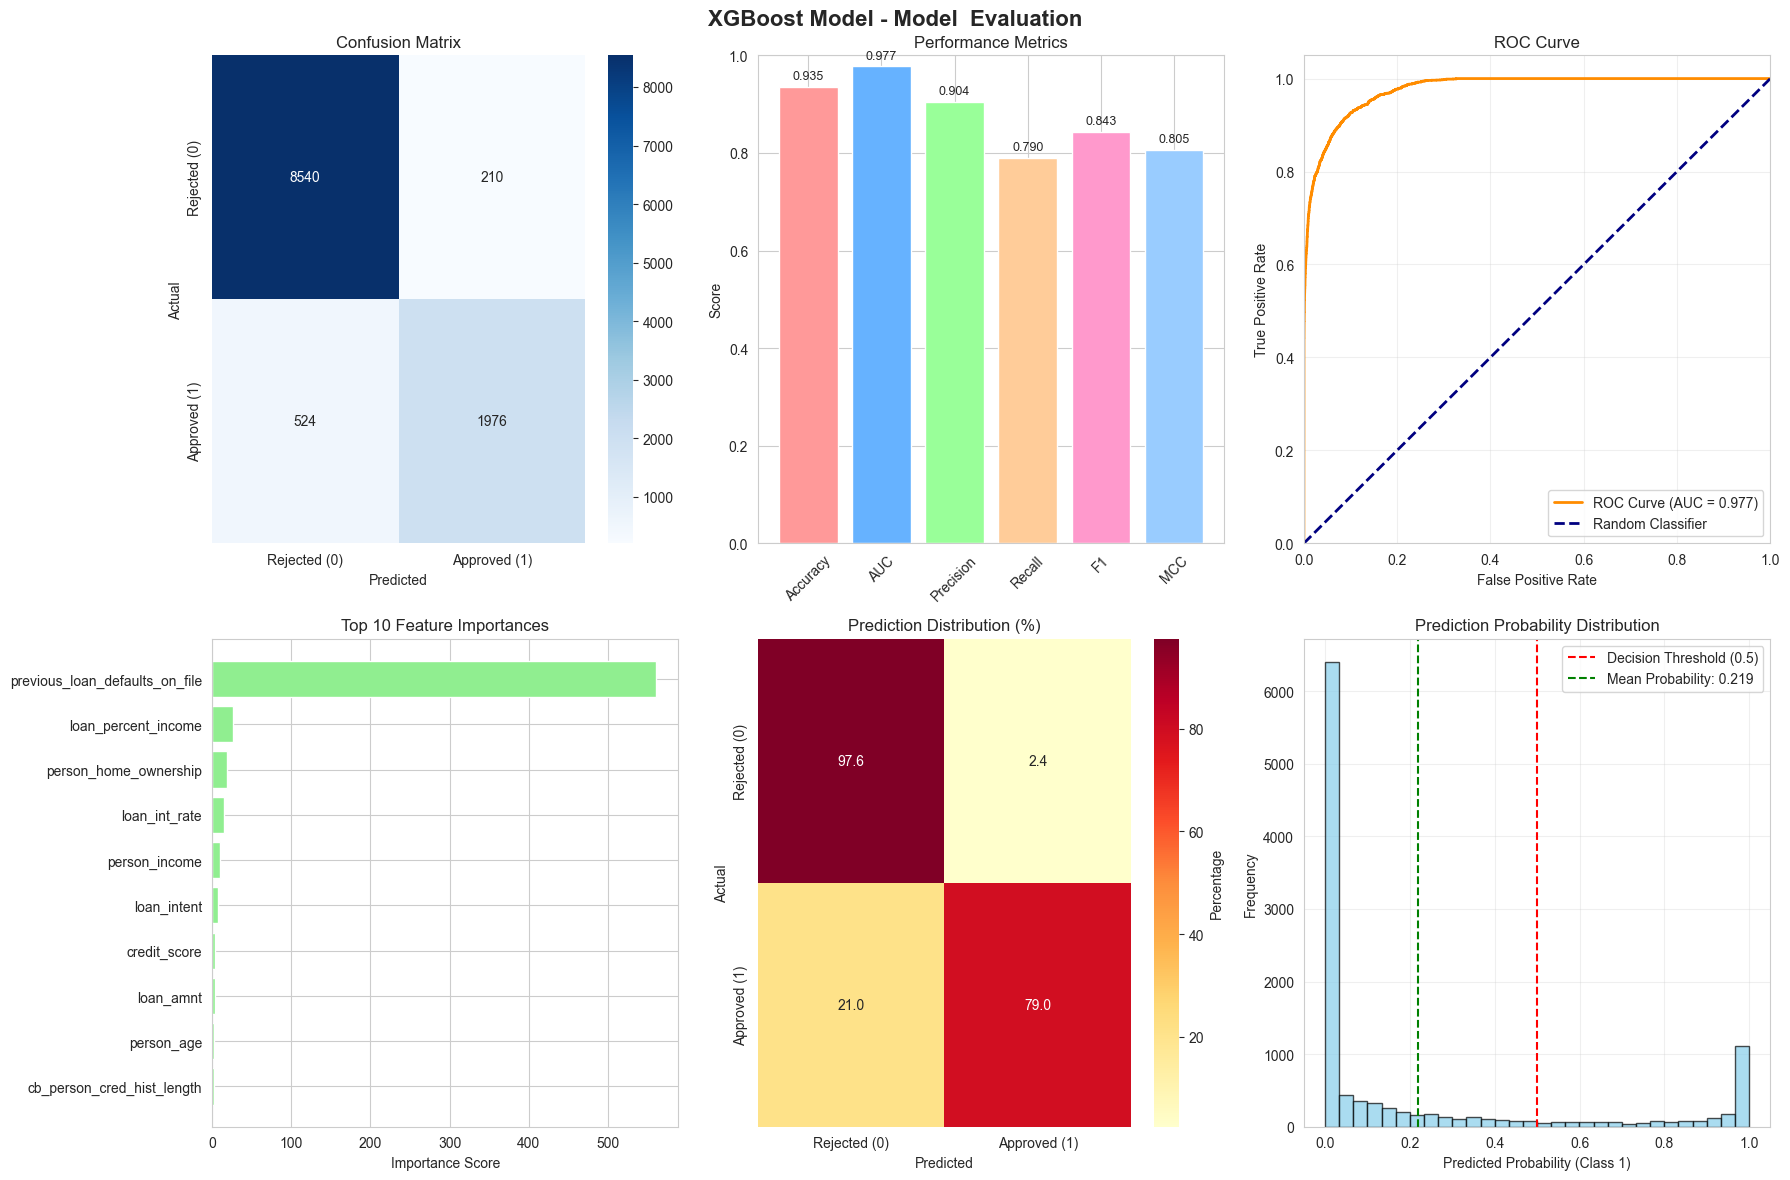

In [12]:
# Step 11
# Model Visualizations
print("MODEL VISUALIZATIONS")
print("=" * 50)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('XGBoost Model - Model  Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# 2. Metrics Comparison
metrics_names = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
metrics_values = [accuracy, roc_auc, precision, recall, f1, mcc]
bars = axes[0,1].bar(metrics_names, metrics_values, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF'])
axes[0,1].set_title('Performance Metrics')
axes[0,1].set_ylabel('Score')
axes[0,1].set_ylim(0, 1)
axes[0,1].tick_params(axis='x', rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{metrics_values[i]:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
axes[0,2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0,2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0,2].set_xlim([0.0, 1.0])
axes[0,2].set_ylim([0.0, 1.05])
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curve')
axes[0,2].legend(loc="lower right")
axes[0,2].grid(True, alpha=0.3)

# 4. Feature Importance (Top 10)
# Get gain and cover importance from booster
booster = xgb_model.get_booster()
try:
    gain_scores = booster.get_score(importance_type='gain')
    cover_scores = booster.get_score(importance_type='cover')
    
    feature_importance_gain = pd.DataFrame(list(gain_scores.items()), columns=['feature', 'importance_gain']).sort_values('importance_gain', ascending=False)
    feature_importance_cover = pd.DataFrame(list(cover_scores.items()), columns=['feature', 'importance_cover']).sort_values('importance_cover', ascending=False)
except:
    # Fallback if get_score doesn't work as expected
    feature_importance_gain = pd.DataFrame({
        'feature': X_train.columns,
        'importance_gain': xgb_model.feature_importances_
    }).sort_values('importance_gain', ascending=False)
    feature_importance_cover = feature_importance_gain.copy()
    feature_importance_cover.columns = ['feature', 'importance_cover']
feature_importance_top10 = feature_importance_gain.head(10)
axes[1,0].barh(range(len(feature_importance_top10)), feature_importance_top10['importance_gain'], color='lightgreen')
axes[1,0].set_yticks(range(len(feature_importance_top10)))
axes[1,0].set_yticklabels(feature_importance_top10['feature'])
axes[1,0].set_title('Top 10 Feature Importances')
axes[1,0].set_xlabel('Importance Score')
axes[1,0].invert_yaxis()

# 5. Prediction Distribution
pred_df = pd.DataFrame({'Actual': y_test.values if hasattr(y_test, 'values') else y_test, 'Predicted': y_pred})
pred_crosstab = pd.crosstab(pred_df['Actual'], pred_df['Predicted'], normalize='index') * 100
sns.heatmap(pred_crosstab, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[1,1], cbar_kws={'label': 'Percentage'})
axes[1,1].set_title('Prediction Distribution (%)')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xlabel('Predicted')

# 6. Prediction Probability Distribution
y_prob = y_pred_proba[:, 1]
axes[1,2].hist(y_prob, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[1,2].axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
axes[1,2].axvline(np.mean(y_prob), color='green', linestyle='--', label=f'Mean Probability: {np.mean(y_prob):.3f}')
axes[1,2].set_title('Prediction Probability Distribution')
axes[1,2].set_xlabel('Predicted Probability (Class 1)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# Step 12: Results Summary 

print(" XGBOOST - Evaluation Metrics Summary")
print("=" * 20)
print(f"Accuracy:  {accuracy:.4f}")
print(f"AUC:       {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

 XGBOOST - Evaluation Metrics Summary
Accuracy:  0.9348
AUC:       0.9774
Precision: 0.9039
Recall:    0.7904
F1-Score:  0.8434
MCC:       0.8053


In [14]:
# Step 13: Save Model to JOBLIB File

# Save the trained model
model_path = '../model/6_xgboost_model.joblib'
joblib.dump(xgb_model, model_path)
print(f"Model saved to: {model_path}")

# Save label encoders
encoders_path = '../model/6_xgboost_encoders.joblib'
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders saved to: {encoders_path}")

Model saved to: ../model/6_xgboost_model.joblib
Label encoders saved to: ../model/6_xgboost_encoders.joblib
